Contexto del caso
UrbanRent Analytics es una empresa española de alquiler de apartamentos turísticos con presencia en cinco ciudades. Gestiona tres tipos de información:

Un fichero CSV con el registro de todas las reservas realizadas durante 2025.
Un fichero CSV con el catálogo de apartamentos disponibles y sus características.
Un fichero JSON con el perfil de los propietarios de cada apartamento.
El equipo de datos acaba de centralizar toda la información en Apache Spark y necesita construir un pipeline de análisis completo para responder preguntas estratégicas de la dirección.

⚠️ Importante: Las preguntas están agrupadas por sesión. Cada sección solo utiliza las herramientas vistas en esa sesión concreta. Trabaja en orden.

In [15]:
// Celda 0 — Inicialización
import $ivy.`org.apache.spark::spark-core:4.1.1`
import $ivy.`org.apache.spark::spark-sql:4.1.1`

import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.expressions.Window
import org.apache.spark.sql.types._

val spark = SparkSession.builder()
  .appName("UrbanRent_Analytics")
  .master("local[*]")
  .config("spark.sql.shuffle.partitions", "4")
  .config("spark.sql.crossJoin.enabled", "true")
  .getOrCreate()

import spark.implicits._
spark.sparkContext.setLogLevel("ERROR")

println(s"✅ UrbanRent Analytics iniciado — Spark ${spark.version} · Scala ${scala.util.Properties.versionString}")

✅ UrbanRent Analytics iniciado — Spark 3.5.0 · Scala version 2.13.18


import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
import org.apache.spark.sql.expressions.Window
import org.apache.spark.sql.types._
spark: SparkSession = org.apache.spark.sql.SparkSession@4c3c47f8
import spark.implicits._

In [ ]:
//reservas
id_reserva,id_apartamento,fecha_entrada,fecha_salida,num_huespedes,precio_noche,canal,valoracion,ciudad
R001,APT001,2025-01-10,2025-01-13,2,95.0,Airbnb,4.8,Madrid
R002,APT002,2025-01-12,2025-01-15,4,120.0,Booking,4.5,Barcelona
R003,APT003,2025-01-20,2025-01-22,1,75.0,Directo,5.0,Valencia
R004,APT001,2025-02-01,2025-02-05,3,95.0,Airbnb,4.7,Madrid
R005,APT004,2025-02-10,2025-02-12,2,110.0,Booking,4.2,Sevilla
R006,APT002,2025-02-14,2025-02-17,5,120.0,Airbnb,4.9,Barcelona
R007,APT005,2025-02-20,2025-02-23,2,85.0,Directo,4.6,Bilbao
R008,APT003,2025-03-01,2025-03-04,1,75.0,Booking,4.4,Valencia
R009,APT001,2025-03-10,2025-03-14,4,95.0,Airbnb,4.8,Madrid
R010,APT006,2025-03-15,2025-03-17,2,130.0,Directo,5.0,Madrid
R011,APT004,2025-03-20,2025-03-22,3,110.0,Airbnb,4.3,Sevilla
R012,APT007,2025-04-01,2025-04-04,2,90.0,Booking,4.5,Barcelona
R013,APT005,2025-04-08,2025-04-10,1,85.0,Directo,4.7,Bilbao
R014,APT006,2025-04-12,2025-04-16,3,130.0,Airbnb,4.9,Madrid
R015,APT002,2025-04-20,2025-04-23,4,120.0,Booking,4.6,Barcelona
R016,APT008,2025-05-01,2025-05-04,2,70.0,Directo,4.1,Valencia
R017,APT003,2025-05-10,2025-05-13,2,75.0,Airbnb,4.5,Valencia
R018,APT007,2025-05-15,2025-05-18,3,90.0,Booking,4.8,Barcelona
R019,APT001,2025-05-20,2025-05-24,2,95.0,Directo,5.0,Madrid
R020,APT009,2025-05-25,2025-05-28,1,65.0,Airbnb,3.9,Bilbao
R021,APT006,2025-06-01,2025-06-05,4,130.0,Booking,4.7,Madrid
R022,APT010,2025-06-08,2025-06-10,2,80.0,Directo,4.3,Sevilla
R023,APT004,2025-06-15,2025-06-18,3,110.0,Airbnb,4.6,Sevilla
R024,APT008,2025-06-20,2025-06-22,1,70.0,Booking,4.2,Valencia
R025,APT005,2025-06-25,2025-06-28,2,85.0,Directo,4.8,Bilbao

In [ ]:
//apartamentos
id_apartamento,tipo,habitaciones,metros_cuadrados,tiene_parking,propietario_id,activo
APT001,Estudio,1,35,false,P01,true
APT002,Piso,3,85,true,P02,true
APT003,Estudio,1,30,false,P01,true
APT004,Piso,2,65,true,P03,true
APT005,Ático,2,70,true,P04,true
APT006,Piso,3,90,true,P02,true
APT007,Estudio,1,28,false,P05,true
APT008,Estudio,1,32,false,P03,false
APT009,Piso,2,55,false,P04,true
APT010,Ático,3,100,true,P05,true

In [ ]:
//propietarios
[
  {"propietario_id": "P01", "nombre": "Laura Sánchez", "ciudad": "Madrid", "antiguedad_anios": 5, "tipo_contrato": "Premium", "especialidades": ["Estudio","Piso"]},
  {"propietario_id": "P02", "nombre": "Carlos Méndez", "ciudad": "Barcelona", "antiguedad_anios": 3, "tipo_contrato": "Estándar", "especialidades": ["Piso"]},
  {"propietario_id": "P03", "nombre": "Ana Ferrero", "ciudad": "Sevilla", "antiguedad_anios": 7, "tipo_contrato": "Premium", "especialidades": ["Piso","Ático"]},
  {"propietario_id": "P04", "nombre": "Javier Ruiz", "ciudad": "Bilbao", "antiguedad_anios": 2, "tipo_contrato": "Estándar", "especialidades": ["Ático","Piso"]},
  {"propietario_id": "P05", "nombre": "Marta Gil", "ciudad": "Valencia", "antiguedad_anios": 6, "tipo_contrato": "Premium", "especialidades": ["Estudio","Ático"]}
]

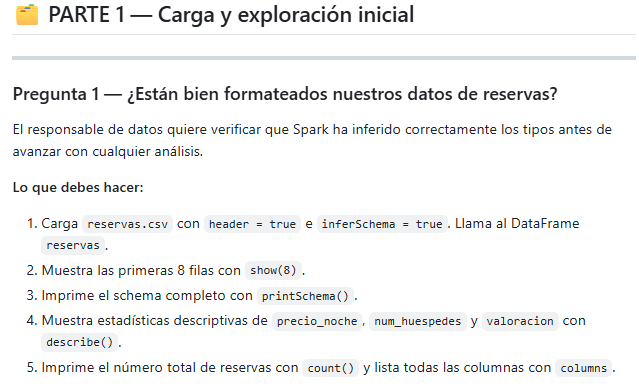

In [23]:
//Pregunta 1
//Datos de caso
import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets

val ruta = "C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala"

Files.createDirectories(Paths.get(ruta))

val contenidoCSV =
"""id_reserva,id_apartamento,fecha_entrada,fecha_salida,num_huespedes,precio_noche,canal,valoracion,ciudad
R001,APT001,2025-01-10,2025-01-13,2,95.0,Airbnb,4.8,Madrid
R002,APT002,2025-01-12,2025-01-15,4,120.0,Booking,4.5,Barcelona
R003,APT003,2025-01-20,2025-01-22,1,75.0,Directo,5.0,Valencia
R004,APT001,2025-02-01,2025-02-05,3,95.0,Airbnb,4.7,Madrid
R005,APT004,2025-02-10,2025-02-12,2,110.0,Booking,4.2,Sevilla
R006,APT002,2025-02-14,2025-02-17,5,120.0,Airbnb,4.9,Barcelona
R007,APT005,2025-02-20,2025-02-23,2,85.0,Directo,4.6,Bilbao
R008,APT003,2025-03-01,2025-03-04,1,75.0,Booking,4.4,Valencia
R009,APT001,2025-03-10,2025-03-14,4,95.0,Airbnb,4.8,Madrid
R010,APT006,2025-03-15,2025-03-17,2,130.0,Directo,5.0,Madrid
R011,APT004,2025-03-20,2025-03-22,3,110.0,Airbnb,4.3,Sevilla
R012,APT007,2025-04-01,2025-04-04,2,90.0,Booking,4.5,Barcelona
R013,APT005,2025-04-08,2025-04-10,1,85.0,Directo,4.7,Bilbao
R014,APT006,2025-04-12,2025-04-16,3,130.0,Airbnb,4.9,Madrid
R015,APT002,2025-04-20,2025-04-23,4,120.0,Booking,4.6,Barcelona
R016,APT008,2025-05-01,2025-05-04,2,70.0,Directo,4.1,Valencia
R017,APT003,2025-05-10,2025-05-13,2,75.0,Airbnb,4.5,Valencia
R018,APT007,2025-05-15,2025-05-18,3,90.0,Booking,4.8,Barcelona
R019,APT001,2025-05-20,2025-05-24,2,95.0,Directo,5.0,Madrid
R020,APT009,2025-05-25,2025-05-28,1,65.0,Airbnb,3.9,Bilbao
R021,APT006,2025-06-01,2025-06-05,4,130.0,Booking,4.7,Madrid
R022,APT010,2025-06-08,2025-06-10,2,80.0,Directo,4.3,Sevilla
R023,APT004,2025-06-15,2025-06-18,3,110.0,Airbnb,4.6,Sevilla
R024,APT008,2025-06-20,2025-06-22,1,70.0,Booking,4.2,Valencia
R025,APT005,2025-06-25,2025-06-28,2,85.0,Directo,4.8,Bilbao
"""

val pathCSV = s"$ruta/reservas.csv"

Files.write(
  Paths.get(pathCSV),
  contenidoCSV.getBytes(StandardCharsets.UTF_8)
)

println(s"CSV creado en: $pathCSV")

CSV creado en: C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala/reservas.csv


import java.nio.file.{Files, Paths}
import java.nio.charset.StandardCharsets
ruta: String = "C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala"
res23_3: java.nio.file.Path = C:\Users\danie\OneDrive\Desktop\Proyectos\practicas\practica_Scala\src\main\scala
contenidoCSV: String = """id_reserva,id_apartamento,fecha_entrada,fecha_salida,num_huespedes,precio_noche,canal,valoracion,ciudad
R001,APT001,2025-01-10,2025-01-13,2,95.0,Airbnb,4.8,Madrid
R002,APT002,2025-01-12,2025-01-15,4,120.0,Booking,4.5,Barcelona
R003,APT003,2025-01-20,2025-01-22,1,75.0,Directo,5.0,Valencia
R004,APT001,2025-02-01,2025-02-05,3,95.0,Airbnb,4.7,Madrid
R005,APT004,2025-02-10,2025-02-12,2,110.0,Booking,4.2,Sevilla
R006,APT002,2025-02-14,2025-02-17,5,120.0,Airbnb,4.9,Barcelona
R007,APT005,2025-02-20,2025-02-23,2,85.0,Directo,4.6,Bilbao
R008,APT003,2025-03-01,2025-03-04,1,75.0,Booking,4.4,Valencia
R009,APT001,2025-03-10,2025-03-14,4,95.0,Airbnb,4.8,Madrid
R010,APT006,2025-03-15,2025-03-1

In [25]:
val reservas = spark.read
  .option("header", "true")
  .option("inferSchema", "true")
  .csv(pathCSV)

println("=== Primeras 8 reservas ===")
reservas.show(8)

println("=== Schema inferido ===")
reservas.printSchema()

println("=== Estadísticas descriptivas ===")
reservas.describe("precio_noche", "num_huespedes", "valoracion").show()

println(s"Total de reservas: ${reservas.count()}")

println("=== Columnas ===")
println(reservas.columns.mkString(" | "))



=== Primeras 8 reservas ===
+----------+--------------+-------------+------------+-------------+------------+-------+----------+---------+
|id_reserva|id_apartamento|fecha_entrada|fecha_salida|num_huespedes|precio_noche|  canal|valoracion|   ciudad|
+----------+--------------+-------------+------------+-------------+------------+-------+----------+---------+
|      R001|        APT001|   2025-01-10|  2025-01-13|            2|        95.0| Airbnb|       4.8|   Madrid|
|      R002|        APT002|   2025-01-12|  2025-01-15|            4|       120.0|Booking|       4.5|Barcelona|
|      R003|        APT003|   2025-01-20|  2025-01-22|            1|        75.0|Directo|       5.0| Valencia|
|      R004|        APT001|   2025-02-01|  2025-02-05|            3|        95.0| Airbnb|       4.7|   Madrid|
|      R005|        APT004|   2025-02-10|  2025-02-12|            2|       110.0|Booking|       4.2|  Sevilla|
|      R006|        APT002|   2025-02-14|  2025-02-17|            5|       120.0| Ai

reservas: org.apache.spark.sql.package.DataFrame = [id_reserva: string, id_apartamento: string ... 7 more fields]

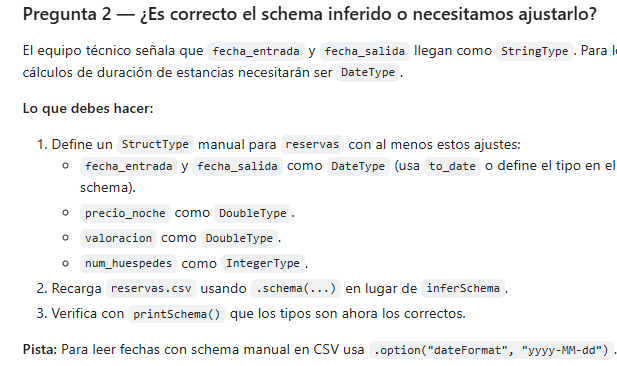

In [27]:
val reservasTyped = spark.read
  .option("header", "true")
  .option("dateFormat", "yyyy-MM-dd")
  .schema(schemaReservas)
  .csv(pathCSV)

  println("=== Schema manual aplicado ===")
reservasTyped.printSchema()

=== Schema manual aplicado ===
root
 |-- id_reserva: string (nullable = true)
 |-- id_apartamento: string (nullable = true)
 |-- fecha_entrada: date (nullable = true)
 |-- fecha_salida: date (nullable = true)
 |-- num_huespedes: integer (nullable = true)
 |-- precio_noche: double (nullable = true)
 |-- canal: string (nullable = true)
 |-- valoracion: double (nullable = true)
 |-- ciudad: string (nullable = true)



reservasTyped: org.apache.spark.sql.package.DataFrame = [id_reserva: string, id_apartamento: string ... 7 more fields]

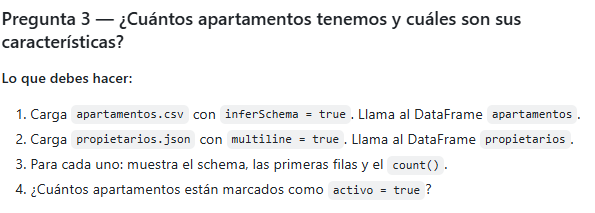

In [30]:
val contenidoApartamentos =
"""id_apartamento,tipo,habitaciones,metros_cuadrados,tiene_parking,propietario_id,activo
APT001,Estudio,1,35,false,P01,true
APT002,Piso,3,85,true,P02,true
APT003,Estudio,1,30,false,P01,true
APT004,Piso,2,65,true,P03,true
APT005,Ático,2,70,true,P04,true
APT006,Piso,3,90,true,P02,true
APT007,Estudio,1,28,false,P05,true
APT008,Estudio,1,32,false,P03,false
APT009,Piso,2,55,false,P04,true
APT010,Ático,3,100,true,P05,true
"""

val pathApartamentos = s"$ruta/apartamentos.csv"

Files.write(
  Paths.get(pathApartamentos),
  contenidoApartamentos.getBytes(StandardCharsets.UTF_8)
)

println(s"CSV creado en: $pathApartamentos")

CSV creado en: C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala/apartamentos.csv


contenidoApartamentos: String = """id_apartamento,tipo,habitaciones,metros_cuadrados,tiene_parking,propietario_id,activo
APT001,Estudio,1,35,false,P01,true
APT002,Piso,3,85,true,P02,true
APT003,Estudio,1,30,false,P01,true
APT004,Piso,2,65,true,P03,true
APT005,Ático,2,70,true,P04,true
APT006,Piso,3,90,true,P02,true
APT007,Estudio,1,28,false,P05,true
APT008,Estudio,1,32,false,P03,false
APT009,Piso,2,55,false,P04,true
APT010,Ático,3,100,true,P05,true
"""
pathApartamentos: String = "C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala/apartamentos.csv"
res30_2: java.nio.file.Path = C:\Users\danie\OneDrive\Desktop\Proyectos\practicas\practica_Scala\src\main\scala\apartamentos.csv

In [31]:
val contenidoPropietarios =
"""[
  {"propietario_id": "P01", "nombre": "Laura Sánchez", "ciudad": "Madrid", "antiguedad_anios": 5, "tipo_contrato": "Premium", "especialidades": ["Estudio","Piso"]},
  {"propietario_id": "P02", "nombre": "Carlos Méndez", "ciudad": "Barcelona", "antiguedad_anios": 3, "tipo_contrato": "Estándar", "especialidades": ["Piso"]},
  {"propietario_id": "P03", "nombre": "Ana Ferrero", "ciudad": "Sevilla", "antiguedad_anios": 7, "tipo_contrato": "Premium", "especialidades": ["Piso","Ático"]},
  {"propietario_id": "P04", "nombre": "Javier Ruiz", "ciudad": "Bilbao", "antiguedad_anios": 2, "tipo_contrato": "Estándar", "especialidades": ["Ático","Piso"]},
  {"propietario_id": "P05", "nombre": "Marta Gil", "ciudad": "Valencia", "antiguedad_anios": 6, "tipo_contrato": "Premium", "especialidades": ["Estudio","Ático"]}
]"""

val pathPropietarios = s"$ruta/propietarios.json"

Files.write(
  Paths.get(pathPropietarios),
  contenidoPropietarios.getBytes(StandardCharsets.UTF_8)
)

println(s"JSON creado en: $pathPropietarios")

JSON creado en: C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala/propietarios.json


contenidoPropietarios: String = """[
  {"propietario_id": "P01", "nombre": "Laura Sánchez", "ciudad": "Madrid", "antiguedad_anios": 5, "tipo_contrato": "Premium", "especialidades": ["Estudio","Piso"]},
  {"propietario_id": "P02", "nombre": "Carlos Méndez", "ciudad": "Barcelona", "antiguedad_anios": 3, "tipo_contrato": "Estándar", "especialidades": ["Piso"]},
  {"propietario_id": "P03", "nombre": "Ana Ferrero", "ciudad": "Sevilla", "antiguedad_anios": 7, "tipo_contrato": "Premium", "especialidades": ["Piso","Ático"]},
  {"propietario_id": "P04", "nombre": "Javier Ruiz", "ciudad": "Bilbao", "antiguedad_anios": 2, "tipo_contrato": "Estándar", "especialidades": ["Ático","Piso"]},
  {"propietario_id": "P05", "nombre": "Marta Gil", "ciudad": "Valencia", "antiguedad_anios": 6, "tipo_contrato": "Premium", "especialidades": ["Estudio","Ático"]}
]"""
pathPropietarios: String = "C:/Users/danie/OneDrive/Desktop/Proyectos/practicas/practica_Scala/src/main/scala/propietarios.json"
res31_2: java.nio.

In [ ]:
//apartamentos
val apartamentos = spark.read
  .option("header", "true")
  .option("inferSchema", "true")
  .csv(pathApartamentos)

  
  apartamentos.show()
  apartamentos.printSchema()
  println(s"Total apartamentos: ${apartamentos.count()}")

+--------------+-------+------------+----------------+-------------+--------------+------+
|id_apartamento|   tipo|habitaciones|metros_cuadrados|tiene_parking|propietario_id|activo|
+--------------+-------+------------+----------------+-------------+--------------+------+
|        APT001|Estudio|           1|              35|        false|           P01|  true|
|        APT002|   Piso|           3|              85|         true|           P02|  true|
|        APT003|Estudio|           1|              30|        false|           P01|  true|
|        APT004|   Piso|           2|              65|         true|           P03|  true|
|        APT005|  Ático|           2|              70|         true|           P04|  true|
|        APT006|   Piso|           3|              90|         true|           P02|  true|
|        APT007|Estudio|           1|              28|        false|           P05|  true|
|        APT008|Estudio|           1|              32|        false|           P03| false|

apartamentos: org.apache.spark.sql.package.DataFrame = [id_apartamento: string, tipo: string ... 5 more fields]

In [33]:
//propietarios
val propietarios = spark.read
  .option("multiline", "true")
  .option("inferSchema", "true")
  .json(pathPropietarios)

propietarios.show()
propietarios.printSchema()

+----------------+---------+----------------+-------------+--------------+-------------+
|antiguedad_anios|   ciudad|  especialidades|       nombre|propietario_id|tipo_contrato|
+----------------+---------+----------------+-------------+--------------+-------------+
|               5|   Madrid| [Estudio, Piso]|Laura Sánchez|           P01|      Premium|
|               3|Barcelona|          [Piso]|Carlos Méndez|           P02|     Estándar|
|               7|  Sevilla|   [Piso, Ático]|  Ana Ferrero|           P03|      Premium|
|               2|   Bilbao|   [Ático, Piso]|  Javier Ruiz|           P04|     Estándar|
|               6| Valencia|[Estudio, Ático]|    Marta Gil|           P05|      Premium|
+----------------+---------+----------------+-------------+--------------+-------------+

root
 |-- antiguedad_anios: long (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- especialidades: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- nombre: str

propietarios: org.apache.spark.sql.package.DataFrame = [antiguedad_anios: bigint, ciudad: string ... 4 more fields]

In [35]:
//apartamentos activos
val apartamentosActivos = apartamentos.rdd.filter(fila => fila.getAs[Boolean]("activo") == true)
println(s"Apartamentos activos: ${apartamentosActivos.count()}")

Apartamentos activos: 9


apartamentosActivos: org.apache.spark.rdd.RDD[org.apache.spark.sql.Row] = MapPartitionsRDD[141] at filter at cmd35.sc:2

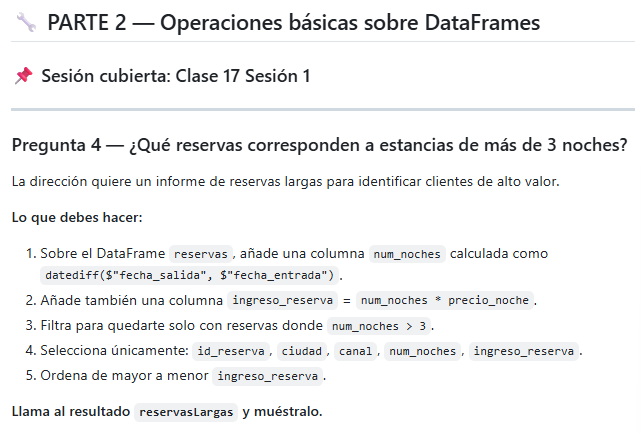

In [36]:
val reservasLargas = reservasTyped
  .withColumn("num_noches", datediff($"fecha_salida", $"fecha_entrada"))
  .withColumn("ingreso_reserva", $"num_noches" * $"precio_noche")
  .filter($"num_noches" > 3)
  .select(
    "id_reserva",
    "ciudad",
    "canal",
    "num_noches",
    "ingreso_reserva"
  )
  .orderBy($"ingreso_reserva".desc)

println("=== Reservas de más de 3 noches ===")
reservasLargas.show()

=== Reservas de más de 3 noches ===
+----------+------+-------+----------+---------------+
|id_reserva|ciudad|  canal|num_noches|ingreso_reserva|
+----------+------+-------+----------+---------------+
|      R014|Madrid| Airbnb|         4|          520.0|
|      R021|Madrid|Booking|         4|          520.0|
|      R004|Madrid| Airbnb|         4|          380.0|
|      R009|Madrid| Airbnb|         4|          380.0|
|      R019|Madrid|Directo|         4|          380.0|
+----------+------+-------+----------+---------------+



reservasLargas: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [id_reserva: string, ciudad: string ... 3 more fields]

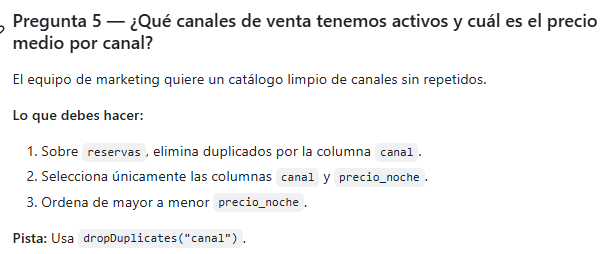

In [37]:
val canalesVenta = reservas
  .dropDuplicates("canal")
  .select("canal", "precio_noche")
  .orderBy($"precio_noche".desc)

println("=== Canales de venta activos ===")
canalesVenta.show()

=== Canales de venta activos ===
+-------+------------+
|  canal|precio_noche|
+-------+------------+
|Booking|       120.0|
| Airbnb|        95.0|
|Directo|        75.0|
+-------+------------+



canalesVenta: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [canal: string, precio_noche: double]

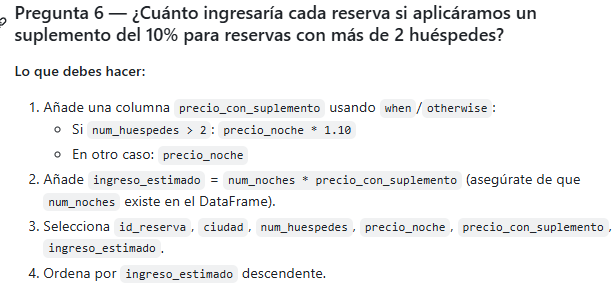

In [38]:
val reservasSuplemento = reservasTyped
  .withColumn(
    "precio_con_suplemento",
    when($"num_huespedes" > 2, $"precio_noche" * 1.10)
      .otherwise($"precio_noche")
  )
  .withColumn(
    "num_noches",
    datediff($"fecha_salida", $"fecha_entrada")
  )
  .withColumn(
    "ingreso_estimado",
    $"num_noches" * $"precio_con_suplemento"
  )
  .select(
    "id_reserva",
    "ciudad",
    "num_huespedes",
    "precio_noche",
    "precio_con_suplemento",
    "ingreso_estimado"
  )
  .orderBy($"ingreso_estimado".desc)

println("=== Ingreso estimado con suplemento ===")
reservasSuplemento.show()

=== Ingreso estimado con suplemento ===
+----------+---------+-------------+------------+---------------------+------------------+
|id_reserva|   ciudad|num_huespedes|precio_noche|precio_con_suplemento|  ingreso_estimado|
+----------+---------+-------------+------------+---------------------+------------------+
|      R014|   Madrid|            3|       130.0|                143.0|             572.0|
|      R021|   Madrid|            4|       130.0|                143.0|             572.0|
|      R004|   Madrid|            3|        95.0|   104.50000000000001|418.00000000000006|
|      R009|   Madrid|            4|        95.0|   104.50000000000001|418.00000000000006|
|      R002|Barcelona|            4|       120.0|                132.0|             396.0|
|      R006|Barcelona|            5|       120.0|                132.0|             396.0|
|      R015|Barcelona|            4|       120.0|                132.0|             396.0|
|      R019|   Madrid|            2|        95.0| 

reservasSuplemento: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [id_reserva: string, ciudad: string ... 4 more fields]

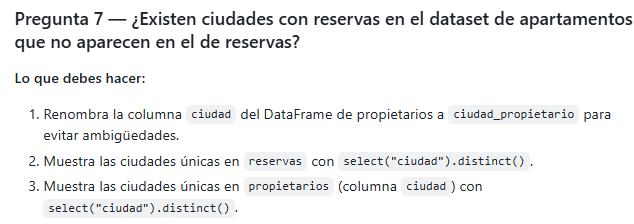

In [39]:
// 1. Renombrar la columna ciudad en propietarios
val propietariosRenombrado = propietarios
  .withColumnRenamed("ciudad", "ciudad_propietario")

// 2. Ciudades únicas en reservas
val ciudadesReservas = reservas
  .select("ciudad")
  .distinct()

println("=== Ciudades únicas en reservas ===")
ciudadesReservas.show()

// 3. Ciudades únicas en propietarios
val ciudadesPropietarios = propietariosRenombrado
  .select("ciudad_propietario")
  .distinct()

println("=== Ciudades únicas en propietarios ===")
ciudadesPropietarios.show()

=== Ciudades únicas en reservas ===
+---------+
|   ciudad|
+---------+
|   Madrid|
|Barcelona|
|   Bilbao|
| Valencia|
|  Sevilla|
+---------+

=== Ciudades únicas en propietarios ===
+------------------+
|ciudad_propietario|
+------------------+
|            Madrid|
|         Barcelona|
|            Bilbao|
|          Valencia|
|           Sevilla|
+------------------+



propietariosRenombrado: org.apache.spark.sql.package.DataFrame = [antiguedad_anios: bigint, ciudad_propietario: string ... 4 more fields]
ciudadesReservas: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad: string]
ciudadesPropietarios: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad_propietario: string]

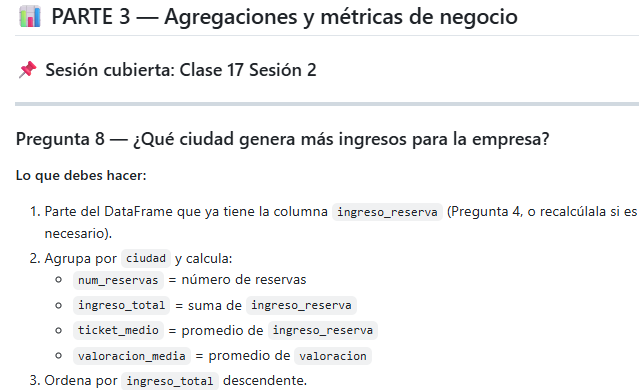

In [40]:
// Recalculamos ingreso_reserva a partir de reservasTyped
val reservasIngresos = reservasTyped
  .withColumn("num_noches", datediff($"fecha_salida", $"fecha_entrada"))
  .withColumn("ingreso_reserva", $"num_noches" * $"precio_noche")

// Agrupación por ciudad con métricas de negocio
val ingresosPorCiudad = reservasIngresos
  .groupBy("ciudad")
  .agg(
    count("id_reserva").as("num_reservas"),
    sum("ingreso_reserva").as("ingreso_total"),
    avg("ingreso_reserva").as("ticket_medio"),
    avg("valoracion").as("valoracion_media")
  )
  .orderBy($"ingreso_total".desc)

println("=== Ingresos por ciudad ===")
ingresosPorCiudad.show()

=== Ingresos por ciudad ===
+---------+------------+-------------+-----------------+------------------+
|   ciudad|num_reservas|ingreso_total|     ticket_medio|  valoracion_media|
+---------+------------+-------------+-----------------+------------------+
|   Madrid|           7|       2725.0|389.2857142857143| 4.842857142857143|
|Barcelona|           5|       1620.0|            324.0|              4.66|
| Valencia|           5|        950.0|            190.0|4.4399999999999995|
|  Sevilla|           4|        930.0|            232.5|              4.35|
|   Bilbao|           4|        875.0|           218.75|               4.5|
+---------+------------+-------------+-----------------+------------------+



reservasIngresos: org.apache.spark.sql.package.DataFrame = [id_reserva: string, id_apartamento: string ... 9 more fields]
ingresosPorCiudad: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad: string, num_reservas: bigint ... 3 more fields]

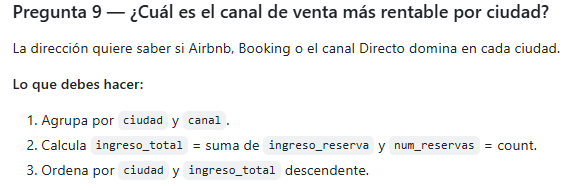

In [41]:
// Partimos del DataFrame que ya tiene ingreso_reserva
val rentabilidadCanalCiudad = reservasIngresos
  .groupBy("ciudad", "canal")
  .agg(
    sum("ingreso_reserva").as("ingreso_total"),
    count("id_reserva").as("num_reservas")
  )
  .orderBy($"ciudad", $"ingreso_total".desc)

println("=== Rentabilidad por canal y ciudad ===")
rentabilidadCanalCiudad.show()

=== Rentabilidad por canal y ciudad ===
+---------+-------+-------------+------------+
|   ciudad|  canal|ingreso_total|num_reservas|
+---------+-------+-------------+------------+
|Barcelona|Booking|       1260.0|           4|
|Barcelona| Airbnb|        360.0|           1|
|   Bilbao|Directo|        680.0|           3|
|   Bilbao| Airbnb|        195.0|           1|
|   Madrid| Airbnb|       1565.0|           4|
|   Madrid|Directo|        640.0|           2|
|   Madrid|Booking|        520.0|           1|
|  Sevilla| Airbnb|        550.0|           2|
|  Sevilla|Booking|        220.0|           1|
|  Sevilla|Directo|        160.0|           1|
| Valencia|Booking|        365.0|           2|
| Valencia|Directo|        360.0|           2|
| Valencia| Airbnb|        225.0|           1|
+---------+-------+-------------+------------+



rentabilidadCanalCiudad: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad: string, canal: string ... 2 more fields]

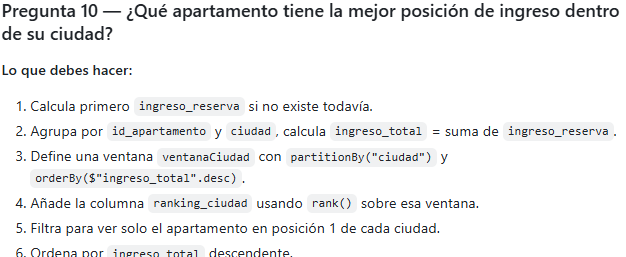

In [42]:
// 1. Aseguramos que exista ingreso_reserva
val reservasIngresos = reservasTyped
  .withColumn("num_noches", datediff($"fecha_salida", $"fecha_entrada"))
  .withColumn("ingreso_reserva", $"num_noches" * $"precio_noche")

// 2. Agrupar por apartamento y ciudad
val ingresosApartamentoCiudad = reservasIngresos
  .groupBy("id_apartamento", "ciudad")
  .agg(
    sum("ingreso_reserva").as("ingreso_total")
  )

// 3. Ventana por ciudad
val ventanaCiudad = Window
  .partitionBy("ciudad")
  .orderBy($"ingreso_total".desc)

// 4, 5 y 6. Ranking, filtrar top 1 y ordenar
val mejorApartamentoPorCiudad = ingresosApartamentoCiudad
  .withColumn("ranking_ciudad", rank().over(ventanaCiudad))
  .filter($"ranking_ciudad" === 1)
  .orderBy($"ingreso_total".desc)

println("=== Mejor apartamento por ciudad ===")
mejorApartamentoPorCiudad.show()

=== Mejor apartamento por ciudad ===
+--------------+---------+-------------+--------------+
|id_apartamento|   ciudad|ingreso_total|ranking_ciudad|
+--------------+---------+-------------+--------------+
|        APT001|   Madrid|       1425.0|             1|
|        APT002|Barcelona|       1080.0|             1|
|        APT004|  Sevilla|        770.0|             1|
|        APT005|   Bilbao|        680.0|             1|
|        APT003| Valencia|        600.0|             1|
+--------------+---------+-------------+--------------+



reservasIngresos: org.apache.spark.sql.package.DataFrame = [id_reserva: string, id_apartamento: string ... 9 more fields]
ingresosApartamentoCiudad: org.apache.spark.sql.package.DataFrame = [id_apartamento: string, ciudad: string ... 1 more field]
ventanaCiudad: org.apache.spark.sql.expressions.WindowSpec = org.apache.spark.sql.expressions.WindowSpec@3852d794
mejorApartamentoPorCiudad: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [id_apartamento: string, ciudad: string ... 2 more fields]

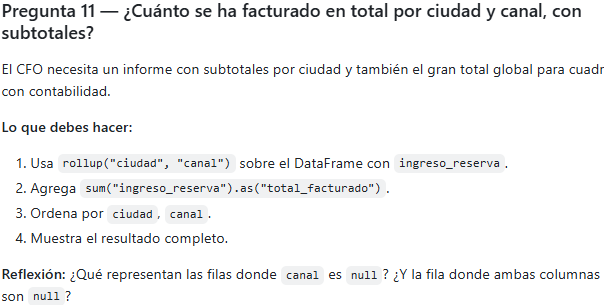

In [43]:
// Rollup para obtener detalle + subtotales + total global
val facturacionRollup = reservasIngresos
  .rollup("ciudad", "canal")
  .agg(
    sum("ingreso_reserva").as("total_facturado")
  )
  .orderBy($"ciudad", $"canal")

println("=== Facturación por ciudad y canal con subtotales ===")
facturacionRollup.show()

=== Facturación por ciudad y canal con subtotales ===
+---------+-------+---------------+
|   ciudad|  canal|total_facturado|
+---------+-------+---------------+
|     NULL|   NULL|         7100.0|
|Barcelona|   NULL|         1620.0|
|Barcelona| Airbnb|          360.0|
|Barcelona|Booking|         1260.0|
|   Bilbao|   NULL|          875.0|
|   Bilbao| Airbnb|          195.0|
|   Bilbao|Directo|          680.0|
|   Madrid|   NULL|         2725.0|
|   Madrid| Airbnb|         1565.0|
|   Madrid|Booking|          520.0|
|   Madrid|Directo|          640.0|
|  Sevilla|   NULL|          930.0|
|  Sevilla| Airbnb|          550.0|
|  Sevilla|Booking|          220.0|
|  Sevilla|Directo|          160.0|
| Valencia|   NULL|          950.0|
| Valencia| Airbnb|          225.0|
| Valencia|Booking|          365.0|
| Valencia|Directo|          360.0|
+---------+-------+---------------+



facturacionRollup: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad: string, canal: string ... 1 more field]

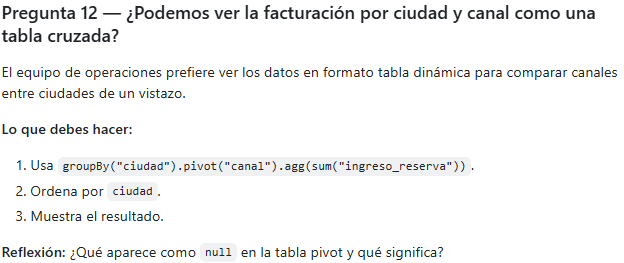

In [46]:
val facturacionPivot = reservasIngresos
  .groupBy("ciudad")
  .pivot("canal")
  .agg(sum("ingreso_reserva"))
  .orderBy("ciudad")

facturacionPivot.show()

+---------+------+-------+-------+
|   ciudad|Airbnb|Booking|Directo|
+---------+------+-------+-------+
|Barcelona| 360.0| 1260.0|   NULL|
|   Bilbao| 195.0|   NULL|  680.0|
|   Madrid|1565.0|  520.0|  640.0|
|  Sevilla| 550.0|  220.0|  160.0|
| Valencia| 225.0|  365.0|  360.0|
+---------+------+-------+-------+



facturacionPivot: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [ciudad: string, Airbnb: double ... 2 more fields]

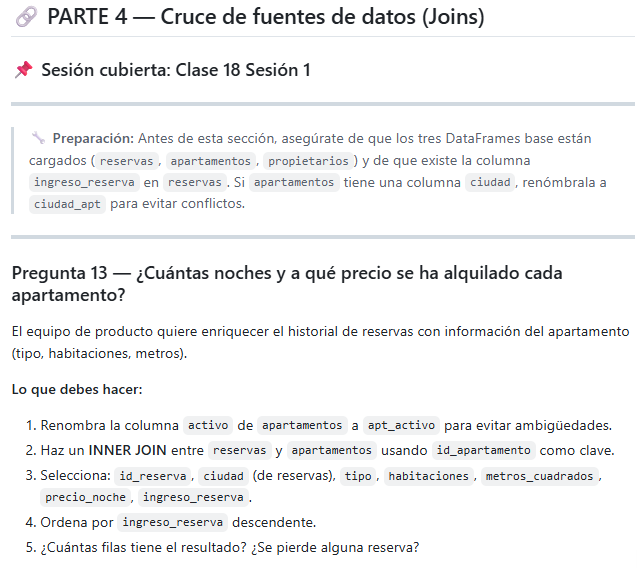

org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `ingreso_reserva` cannot be resolved. Did you mean one of the following? [`id_reserva`, `id_apartamento`, `fecha_entrada`, `fecha_salida`, `num_huespedes`, `precio_noche`, `canal`, `valoracion`, `ciudad`].